In [4]:
import os
import numpy as np
from tensorflow.keras.models import load_model
import tensorflow as tf
import pandas as pd

In [ ]:
# ## set gpu
# gpu = 1
# os.environ["CUDA_DEVICE_ORDER"]="PCI_BUS_ID"   
# os.environ["CUDA_VISIBLE_DEVICES"] = f"{gpu}" 
# physical_devices = tf.config.list_physical_devices('GPU') 
# print(tf.test.is_gpu_available(cuda_only=False, min_cuda_compute_capability=None))
# print("Num GPUs:", len(physical_devices))

In [5]:
## set gpu
os.environ["CUDA_DEVICE_ORDER"]="PCI_BUS_ID"   
os.environ["CUDA_VISIBLE_DEVICES"] = "" 
physical_devices = tf.config.list_physical_devices('GPU') 
print(tf.test.is_gpu_available(cuda_only=False, min_cuda_compute_capability=None))
print("Num GPUs:", len(physical_devices))

Instructions for updating:
Use `tf.config.list_physical_devices('GPU')` instead.
False
Num GPUs: 0


# ⚙️ Load model

In [6]:
model_dir = "/media/tohn/HDD2/Model_unlearn/ResNet152v2Model/baseML_unlearn/R2/unfreeze_conv1-conv3_block/models"
model_path = f"{model_dir}/modelResNet152v2_Unlearning_miniImageNet-R2.h5"
print(f"Load Model: {model_path}")
model = load_model(model_path)
height = width = model.input_shape[1]
print(height, width)
model.summary()

Load Model: /media/tohn/HDD2/Model_unlearn/ResNet152v2Model/baseML_unlearn/R2/unfreeze_conv1-conv3_block/models/modelResNet152v2_Unlearning_miniImageNet-R2.h5
(None, 224, 224, 3) (None, 224, 224, 3)
Model: "ResNet152v2-Unlearn"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_1 (InputLayer)            [(None, 224, 224, 3) 0                                            
__________________________________________________________________________________________________
input_2 (InputLayer)            [(None, 224, 224, 3) 0                                            
__________________________________________________________________________________________________
concatenate (Concatenate)       (None, 224, 224, 6)  0           input_1[0][0]                    
                                                                 input_2[0][0] 

# 📂 Load datatest

In [7]:
TESTdf = pd.read_csv("/home/kannika/code/DATATEST-V2_mini_ImageNet_MachineUnlearn.csv", dtype=str)
print(TESTdf.shape)
TESTdf.head()

(6000, 8)


,Unnamed: 0,Unnamed: 0.1,filename,img_path_main,img_path_2,cls,encode_label,subset
0,0,0,n0444325700001113,/media/tohn/HDD2/miniImageNet_Dataset/mini-ima...,/media/tohn/HDD2/miniImageNet_Dataset/mini-ima...,TRUE,1,test
1,1,1,n0444325700000041,/media/tohn/HDD2/miniImageNet_Dataset/mini-ima...,/media/tohn/HDD2/miniImageNet_Dataset/mini-ima...,TRUE,1,test
2,2,2,n0444325700000976,/media/tohn/HDD2/miniImageNet_Dataset/mini-ima...,/media/tohn/HDD2/miniImageNet_Dataset/mini-ima...,TRUE,1,test
3,3,3,n0444325700000294,/media/tohn/HDD2/miniImageNet_Dataset/mini-ima...,/media/tohn/HDD2/miniImageNet_Dataset/mini-ima...,TRUE,1,test
4,4,4,n0444325700000506,/media/tohn/HDD2/miniImageNet_Dataset/mini-ima...,/media/tohn/HDD2/miniImageNet_Dataset/mini-ima...,TRUE,1,test


In [6]:
print(TESTdf['cls'].value_counts())

TRUE     3000
FALSE    3000
Name: cls, dtype: int64


In [7]:
#TESTdf01 = TESTdf.sample(100, replace=False)
TESTdf01 = TESTdf.iloc[:2000,:]
TESTdf01 = TESTdf01.reset_index(drop=True)
print(TESTdf01.shape)
TESTdf01.tail()

(2000, 8)


,Unnamed: 0,Unnamed: 0.1,filename,img_path_main,img_path_2,cls,encode_label,subset
1995,1995,1995,n0213844100001199,/media/tohn/HDD2/miniImageNet_Dataset/mini-ima...,/media/tohn/HDD2/miniImageNet_Dataset/mini-ima...,FALSE,0,test
1996,1996,1996,n0213844100000746,/media/tohn/HDD2/miniImageNet_Dataset/mini-ima...,/media/tohn/HDD2/miniImageNet_Dataset/mini-ima...,FALSE,0,test
1997,1997,1997,n0213844100000842,/media/tohn/HDD2/miniImageNet_Dataset/mini-ima...,/media/tohn/HDD2/miniImageNet_Dataset/mini-ima...,FALSE,0,test
1998,1998,1998,n0213844100000232,/media/tohn/HDD2/miniImageNet_Dataset/mini-ima...,/media/tohn/HDD2/miniImageNet_Dataset/mini-ima...,FALSE,0,test
1999,1999,1999,n0213844100000277,/media/tohn/HDD2/miniImageNet_Dataset/mini-ima...,/media/tohn/HDD2/miniImageNet_Dataset/mini-ima...,FALSE,0,test


In [8]:
TESTdf02 = TESTdf.iloc[2000:4000,:]
TESTdf02 = TESTdf02.reset_index(drop=True)
print(TESTdf02.shape)
TESTdf02

(2000, 8)


,Unnamed: 0,Unnamed: 0.1,filename,img_path_main,img_path_2,cls,encode_label,subset
0,2000,2000,n0213844100000648,/media/tohn/HDD2/miniImageNet_Dataset/mini-ima...,/media/tohn/HDD2/miniImageNet_Dataset/mini-ima...,FALSE,0,test
1,2001,2001,n0213844100000166,/media/tohn/HDD2/miniImageNet_Dataset/mini-ima...,/media/tohn/HDD2/miniImageNet_Dataset/mini-ima...,FALSE,0,test
2,2002,2002,n0213844100000995,/media/tohn/HDD2/miniImageNet_Dataset/mini-ima...,/media/tohn/HDD2/miniImageNet_Dataset/mini-ima...,FALSE,0,test
3,2003,2003,n0213844100000852,/media/tohn/HDD2/miniImageNet_Dataset/mini-ima...,/media/tohn/HDD2/miniImageNet_Dataset/mini-ima...,FALSE,0,test
4,2004,2004,n0213844100001017,/media/tohn/HDD2/miniImageNet_Dataset/mini-ima...,/media/tohn/HDD2/miniImageNet_Dataset/mini-ima...,FALSE,0,test
...,...,...,...,...,...,...,...,...
1995,3995,3995,n0758411000000539,/media/tohn/HDD2/miniImageNet_Dataset/mini-ima...,/media/tohn/HDD2/miniImageNet_Dataset/mini-ima...,FALSE,0,test
1996,3996,3996,n0758411000000035,/media/tohn/HDD2/miniImageNet_Dataset/mini-ima...,/media/tohn/HDD2/miniImageNet_Dataset/mini-ima...,FALSE,0,test
1997,3997,3997,n0758411000001015,/media/tohn/HDD2/miniImageNet_Dataset/mini-ima...,/media/tohn/HDD2/miniImageNet_Dataset/mini-ima...,FALSE,0,test
1998,3998,3998,n0758411000000131,/media/tohn/HDD2/miniImageNet_Dataset/mini-ima...,/media/tohn/HDD2/miniImageNet_Dataset/mini-ima...,FALSE,0,test


In [8]:
TESTdf03 = TESTdf.iloc[4000:,:]
TESTdf03 = TESTdf03.reset_index(drop=True)
print(TESTdf03.shape)
TESTdf03

(2000, 8)


,Unnamed: 0,Unnamed: 0.1,filename,img_path_main,img_path_2,cls,encode_label,subset
0,4000,4000,n0758411000001134,/media/tohn/HDD2/miniImageNet_Dataset/mini-ima...,/media/tohn/HDD2/miniImageNet_Dataset/mini-ima...,FALSE,0,test
1,4001,4001,n0758411000000741,/media/tohn/HDD2/miniImageNet_Dataset/mini-ima...,/media/tohn/HDD2/miniImageNet_Dataset/mini-ima...,FALSE,0,test
2,4002,4002,n0758411000000327,/media/tohn/HDD2/miniImageNet_Dataset/mini-ima...,/media/tohn/HDD2/miniImageNet_Dataset/mini-ima...,FALSE,0,test
3,4003,4003,n0758411000001197,/media/tohn/HDD2/miniImageNet_Dataset/mini-ima...,/media/tohn/HDD2/miniImageNet_Dataset/mini-ima...,FALSE,0,test
4,4004,4004,n0758411000000150,/media/tohn/HDD2/miniImageNet_Dataset/mini-ima...,/media/tohn/HDD2/miniImageNet_Dataset/mini-ima...,TRUE,1,test
...,...,...,...,...,...,...,...,...
1995,5995,5995,n0444325700000026,/media/tohn/HDD2/miniImageNet_Dataset/mini-ima...,/media/tohn/HDD2/miniImageNet_Dataset/mini-ima...,TRUE,1,test
1996,5996,5996,n0444325700000332,/media/tohn/HDD2/miniImageNet_Dataset/mini-ima...,/media/tohn/HDD2/miniImageNet_Dataset/mini-ima...,TRUE,1,test
1997,5997,5997,n0444325700000705,/media/tohn/HDD2/miniImageNet_Dataset/mini-ima...,/media/tohn/HDD2/miniImageNet_Dataset/mini-ima...,TRUE,1,test
1998,5998,5998,n0444325700000354,/media/tohn/HDD2/miniImageNet_Dataset/mini-ima...,/media/tohn/HDD2/miniImageNet_Dataset/mini-ima...,TRUE,1,test


## ⚙️ Function: Prepare Batch Test

In [9]:
from tensorflow.keras.preprocessing import image

def TENSOR_image(img_path):
    # Read the image and resize it
    img = image.load_img(img_path, target_size=(height, width))
    # Convert it to a Numpy array with target shape.
    x = image.img_to_array(img)
    # Reshape
    x = x.reshape((1,) + x.shape)
    x /= 255.

    return x

In [10]:
def preparebatch(TESTdf):
    listimg_test = []
    for j in range(len(TESTdf)):
        pathimgmain = TESTdf["img_path_main"][j]
        x_main = TENSOR_image(pathimgmain)
        pathimg2 = TESTdf["img_path_2"][j]
        x_2 = TENSOR_image(pathimg2)
        img_test = [x_main, x_2]
        listimg_test.append(img_test)
        
    return listimg_test

In [11]:
## Setting input shape
height = width = model.input_shape[0][1]
print(height, width)

224 224


In [13]:
listimg_test01=preparebatch(TESTdf01)
print(len(listimg_test01))

2000


In [23]:
listimg_test02=preparebatch(TESTdf02)
print(len(listimg_test02))

2000


In [12]:
listimg_test03=preparebatch(TESTdf03)
print(len(listimg_test03))

2000


In [ ]:
print(len(listimg_test01)+len(listimg_test02)+len(listimg_test03))

## 💡 Prediction

In [13]:
def predicted(listimg_test):
    pred_list = list()
    prob_list = list()

    for i in range(0, len(listimg_test)):
        if i+1 % 100 == 0:
            print(f"Predict image batch: {i+1}") 
        predict = model.predict(listimg_test[i]) 
        predict0 = predict[0][0]
        prob_list.append(predict0)
        if predict0 > 0.5:
            pred_list.append("TRUE")
        else:
            pred_list.append("FALSE")
            
    return pred_list, prob_list

In [20]:
pred_list01, prob_list01 = predicted(listimg_test01)
print(len(pred_list01))
print(len(prob_list01))

2000
2000


In [24]:
pred_list02, prob_list02 = predicted(listimg_test02)
print(len(pred_list02))
print(len(prob_list02))

2000
2000


In [14]:
pred_list03, prob_list03 = predicted(listimg_test03)
print(len(pred_list03))
print(len(prob_list03))

2000
2000


--------

In [21]:
TESTdf01['category'] = pred_list01
TESTdf01['Prob'] = prob_list01
TESTdf01.head()

,Unnamed: 0,Unnamed: 0.1,filename,img_path_main,img_path_2,cls,encode_label,subset,category,Prob
0,0,0,n0444325700001113,/media/tohn/HDD2/miniImageNet_Dataset/mini-ima...,/media/tohn/HDD2/miniImageNet_Dataset/mini-ima...,TRUE,1,test,TRUE,0.853265
1,1,1,n0444325700000041,/media/tohn/HDD2/miniImageNet_Dataset/mini-ima...,/media/tohn/HDD2/miniImageNet_Dataset/mini-ima...,TRUE,1,test,FALSE,0.348142
2,2,2,n0444325700000976,/media/tohn/HDD2/miniImageNet_Dataset/mini-ima...,/media/tohn/HDD2/miniImageNet_Dataset/mini-ima...,TRUE,1,test,FALSE,0.339611
3,3,3,n0444325700000294,/media/tohn/HDD2/miniImageNet_Dataset/mini-ima...,/media/tohn/HDD2/miniImageNet_Dataset/mini-ima...,TRUE,1,test,FALSE,0.107220
4,4,4,n0444325700000506,/media/tohn/HDD2/miniImageNet_Dataset/mini-ima...,/media/tohn/HDD2/miniImageNet_Dataset/mini-ima...,TRUE,1,test,TRUE,0.793618


In [25]:
TESTdf02['category'] = pred_list02
TESTdf02['Prob'] = prob_list02
TESTdf02.head()

,Unnamed: 0,Unnamed: 0.1,filename,img_path_main,img_path_2,cls,encode_label,subset,category,Prob
0,2000,2000,n0213844100000648,/media/tohn/HDD2/miniImageNet_Dataset/mini-ima...,/media/tohn/HDD2/miniImageNet_Dataset/mini-ima...,FALSE,0,test,FALSE,0.127945
1,2001,2001,n0213844100000166,/media/tohn/HDD2/miniImageNet_Dataset/mini-ima...,/media/tohn/HDD2/miniImageNet_Dataset/mini-ima...,FALSE,0,test,FALSE,0.075386
2,2002,2002,n0213844100000995,/media/tohn/HDD2/miniImageNet_Dataset/mini-ima...,/media/tohn/HDD2/miniImageNet_Dataset/mini-ima...,FALSE,0,test,FALSE,0.127375
3,2003,2003,n0213844100000852,/media/tohn/HDD2/miniImageNet_Dataset/mini-ima...,/media/tohn/HDD2/miniImageNet_Dataset/mini-ima...,FALSE,0,test,FALSE,0.189535
4,2004,2004,n0213844100001017,/media/tohn/HDD2/miniImageNet_Dataset/mini-ima...,/media/tohn/HDD2/miniImageNet_Dataset/mini-ima...,FALSE,0,test,FALSE,0.113706


In [15]:
TESTdf03['category'] = pred_list03
TESTdf03['Prob'] = prob_list03
TESTdf03.head()

,Unnamed: 0,Unnamed: 0.1,filename,img_path_main,img_path_2,cls,encode_label,subset,category,Prob
0,4000,4000,n0758411000001134,/media/tohn/HDD2/miniImageNet_Dataset/mini-ima...,/media/tohn/HDD2/miniImageNet_Dataset/mini-ima...,FALSE,0,test,FALSE,0.103746
1,4001,4001,n0758411000000741,/media/tohn/HDD2/miniImageNet_Dataset/mini-ima...,/media/tohn/HDD2/miniImageNet_Dataset/mini-ima...,FALSE,0,test,FALSE,0.174827
2,4002,4002,n0758411000000327,/media/tohn/HDD2/miniImageNet_Dataset/mini-ima...,/media/tohn/HDD2/miniImageNet_Dataset/mini-ima...,FALSE,0,test,FALSE,0.141729
3,4003,4003,n0758411000001197,/media/tohn/HDD2/miniImageNet_Dataset/mini-ima...,/media/tohn/HDD2/miniImageNet_Dataset/mini-ima...,FALSE,0,test,FALSE,0.134877
4,4004,4004,n0758411000000150,/media/tohn/HDD2/miniImageNet_Dataset/mini-ima...,/media/tohn/HDD2/miniImageNet_Dataset/mini-ima...,TRUE,1,test,FALSE,0.108602


In [22]:
TESTdf01.to_csv("/home/kannika/code/ResNet152v2_predict_mini-ImageNet_MachineUnlearn_R2_Unfreezeconv1x-conv3_block_TEST01.csv")

In [26]:
TESTdf02.to_csv("/home/kannika/code/ResNet152v2_predict_mini-ImageNet_MachineUnlearn_R2_Unfreezeconv1x-conv3_block_TEST02.csv")

In [16]:
TESTdf03.to_csv("/home/kannika/code/ResNet152v2_predict_mini-ImageNet_MachineUnlearn_R2_Unfreezeconv1x-conv3_block_TEST03.csv")

--------------

In [17]:
TESTdf01 = pd.read_csv("/home/kannika/code/ResNet152v2_predict_mini-ImageNet_MachineUnlearn_R2_Unfreezeconv1x-conv3_block_TEST01.csv", dtype=str)
print(TESTdf01.shape)
TESTdf01.head()

(2000, 11)


,Unnamed: 0,Unnamed: 0.1,Unnamed: 0.1.1,filename,img_path_main,img_path_2,cls,encode_label,subset,category,Prob
0,0,0,0,n0444325700001113,/media/tohn/HDD2/miniImageNet_Dataset/mini-ima...,/media/tohn/HDD2/miniImageNet_Dataset/mini-ima...,TRUE,1,test,TRUE,0.8532647490501404
1,1,1,1,n0444325700000041,/media/tohn/HDD2/miniImageNet_Dataset/mini-ima...,/media/tohn/HDD2/miniImageNet_Dataset/mini-ima...,TRUE,1,test,FALSE,0.348142147064209
2,2,2,2,n0444325700000976,/media/tohn/HDD2/miniImageNet_Dataset/mini-ima...,/media/tohn/HDD2/miniImageNet_Dataset/mini-ima...,TRUE,1,test,FALSE,0.33961087465286255
3,3,3,3,n0444325700000294,/media/tohn/HDD2/miniImageNet_Dataset/mini-ima...,/media/tohn/HDD2/miniImageNet_Dataset/mini-ima...,TRUE,1,test,FALSE,0.10722005367279053
4,4,4,4,n0444325700000506,/media/tohn/HDD2/miniImageNet_Dataset/mini-ima...,/media/tohn/HDD2/miniImageNet_Dataset/mini-ima...,TRUE,1,test,TRUE,0.7936176061630249


In [18]:
TESTdf02 = pd.read_csv("/home/kannika/code/ResNet152v2_predict_mini-ImageNet_MachineUnlearn_R2_Unfreezeconv1x-conv3_block_TEST02.csv", dtype=str)
print(TESTdf02.shape)
TESTdf02.head()

(2000, 11)


,Unnamed: 0,Unnamed: 0.1,Unnamed: 0.1.1,filename,img_path_main,img_path_2,cls,encode_label,subset,category,Prob
0,0,2000,2000,n0213844100000648,/media/tohn/HDD2/miniImageNet_Dataset/mini-ima...,/media/tohn/HDD2/miniImageNet_Dataset/mini-ima...,FALSE,0,test,FALSE,0.12794533371925354
1,1,2001,2001,n0213844100000166,/media/tohn/HDD2/miniImageNet_Dataset/mini-ima...,/media/tohn/HDD2/miniImageNet_Dataset/mini-ima...,FALSE,0,test,FALSE,0.07538589835166931
2,2,2002,2002,n0213844100000995,/media/tohn/HDD2/miniImageNet_Dataset/mini-ima...,/media/tohn/HDD2/miniImageNet_Dataset/mini-ima...,FALSE,0,test,FALSE,0.12737450003623962
3,3,2003,2003,n0213844100000852,/media/tohn/HDD2/miniImageNet_Dataset/mini-ima...,/media/tohn/HDD2/miniImageNet_Dataset/mini-ima...,FALSE,0,test,FALSE,0.1895352602005005
4,4,2004,2004,n0213844100001017,/media/tohn/HDD2/miniImageNet_Dataset/mini-ima...,/media/tohn/HDD2/miniImageNet_Dataset/mini-ima...,FALSE,0,test,FALSE,0.11370581388473511


In [19]:
TESTdf03 = pd.read_csv("/home/kannika/code/ResNet152v2_predict_mini-ImageNet_MachineUnlearn_R2_Unfreezeconv1x-conv3_block_TEST03.csv", dtype=str)
print(TESTdf03.shape)
TESTdf03.head()

(2000, 11)


,Unnamed: 0,Unnamed: 0.1,Unnamed: 0.1.1,filename,img_path_main,img_path_2,cls,encode_label,subset,category,Prob
0,0,4000,4000,n0758411000001134,/media/tohn/HDD2/miniImageNet_Dataset/mini-ima...,/media/tohn/HDD2/miniImageNet_Dataset/mini-ima...,FALSE,0,test,FALSE,0.10374569892883301
1,1,4001,4001,n0758411000000741,/media/tohn/HDD2/miniImageNet_Dataset/mini-ima...,/media/tohn/HDD2/miniImageNet_Dataset/mini-ima...,FALSE,0,test,FALSE,0.1748274266719818
2,2,4002,4002,n0758411000000327,/media/tohn/HDD2/miniImageNet_Dataset/mini-ima...,/media/tohn/HDD2/miniImageNet_Dataset/mini-ima...,FALSE,0,test,FALSE,0.1417292058467865
3,3,4003,4003,n0758411000001197,/media/tohn/HDD2/miniImageNet_Dataset/mini-ima...,/media/tohn/HDD2/miniImageNet_Dataset/mini-ima...,FALSE,0,test,FALSE,0.134876549243927
4,4,4004,4004,n0758411000000150,/media/tohn/HDD2/miniImageNet_Dataset/mini-ima...,/media/tohn/HDD2/miniImageNet_Dataset/mini-ima...,TRUE,1,test,FALSE,0.10860225558280945


In [20]:
df_TEST = pd.concat([TESTdf01, TESTdf02, TESTdf03])
print(df_TEST.shape)
df_TEST.head()

(6000, 11)


,Unnamed: 0,Unnamed: 0.1,Unnamed: 0.1.1,filename,img_path_main,img_path_2,cls,encode_label,subset,category,Prob
0,0,0,0,n0444325700001113,/media/tohn/HDD2/miniImageNet_Dataset/mini-ima...,/media/tohn/HDD2/miniImageNet_Dataset/mini-ima...,TRUE,1,test,TRUE,0.8532647490501404
1,1,1,1,n0444325700000041,/media/tohn/HDD2/miniImageNet_Dataset/mini-ima...,/media/tohn/HDD2/miniImageNet_Dataset/mini-ima...,TRUE,1,test,FALSE,0.348142147064209
2,2,2,2,n0444325700000976,/media/tohn/HDD2/miniImageNet_Dataset/mini-ima...,/media/tohn/HDD2/miniImageNet_Dataset/mini-ima...,TRUE,1,test,FALSE,0.33961087465286255
3,3,3,3,n0444325700000294,/media/tohn/HDD2/miniImageNet_Dataset/mini-ima...,/media/tohn/HDD2/miniImageNet_Dataset/mini-ima...,TRUE,1,test,FALSE,0.10722005367279053
4,4,4,4,n0444325700000506,/media/tohn/HDD2/miniImageNet_Dataset/mini-ima...,/media/tohn/HDD2/miniImageNet_Dataset/mini-ima...,TRUE,1,test,TRUE,0.7936176061630249


In [21]:
set(df_TEST["category"])

{'FALSE', 'TRUE'}

In [22]:
df_TEST.to_csv("/home/kannika/code/ResNet152v2_predict_mini-ImageNet_MachineUnlearn_R2_Unfreezeconv1x-conv3_block_TEST.csv")

----------------

# Evaluation

In [24]:
import numpy as np
from sklearn.metrics import confusion_matrix

act = df_TEST['cls'].array
pred = df_TEST['category'].array

cmat = confusion_matrix(act, pred)
print('classifier accuracy = {}%'.format((100.*np.trace(cmat))/(np.sum(cmat))))

#Marking the Confusion Matrix
from sklearn.metrics import classification_report,confusion_matrix
print(classification_report(act, pred))  #performance

classifier accuracy = 82.15%
              precision    recall  f1-score   support

       FALSE       0.74      0.99      0.85      3000
        TRUE       0.99      0.65      0.78      3000

    accuracy                           0.82      6000
   macro avg       0.86      0.82      0.82      6000
weighted avg       0.86      0.82      0.82      6000



## Confusion matrix

Text(0.5, 21.5, 'Predicted label')

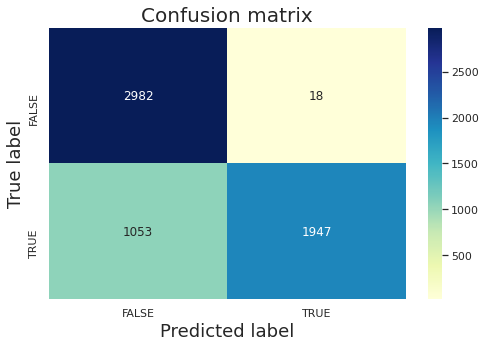

In [25]:
#create CF 
data = {'Actual': act,'Predicted' : pred,}
df = pd.DataFrame(data, columns=['Actual','Predicted'])
conf_mat = pd.crosstab(df['Actual'],df['Predicted'],rownames=['Actual'],colnames=['Predicted'])

#Confusion matrix
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
cm = confusion_matrix(act, pred)

#plot Confusion matrix
import seaborn as sns
sns.set()
fig, ax = plt.subplots(figsize=(8, 5))

ax = sns.heatmap(conf_mat, annot=True, fmt="d", cmap="YlGnBu") #Blues,Oranges,Reds
ax.set_title('Confusion matrix',fontsize=20)
ax.set_ylabel('True label',fontsize=18)
ax.set_xlabel('Predicted label',fontsize=18)

In [26]:
tn, fp, fn, tp = confusion_matrix(act, pred).ravel()
print("True Negative (TN):", tn)
print("False Positive (FP):", fp)
print("False Negative (FN):", fn)
print("True Positive: (TP)", tp)

True Negative (TN): 2982
False Positive (FP): 18
False Negative (FN): 1053
True Positive: (TP) 1947
